Simple XAI for Transformer model using SHAP

### Define Transformer model

In [33]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import shap

In [34]:
# Define a dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        # Ensure slicing works correctly
        return (
            self.data[idx:idx + self.seq_length, :], 
            self.data[idx + self.seq_length, :]     
        )

In [35]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout):
        super(TransformerModel, self).__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 5000, d_model))
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, src):
        src_emb = self.input_embedding(src) + self.positional_encoding[:, :src.size(1), :]
        src_emb = src_emb.permute(1, 0, 2)
        transformer_out = self.transformer(src_emb, src_emb)
        output = self.fc_out(transformer_out[-1, :, :])
        return output.squeeze(-1)

In [38]:
# Generate synthetic data with 21 dimensions
def generate_data():
    np.random.seed(42)
    time = np.arange(0, 1000)
    data = np.array([np.sin(0.02 * time + i) + np.random.normal(0, 0.1, size=time.shape) for i in range(21)]).T
    return data
data = generate_data()
data.shape

(1000, 21)

In [39]:
data.shape

(1000, 21)

In [40]:
data[1].shape

(21,)

### Generation data

In [42]:
data = generate_data()
data_tensor = torch.tensor(data, dtype=torch.float32).unsqueeze(-1)

In [43]:
data_tensor.shape

torch.Size([1000, 21, 1])

### Define Parameters for TF model

In [44]:
# Transformer parameters
input_dim = 21
d_model = 64
nhead = 4
num_layers = 2
dim_feedforward = 256
dropout = 0.1
learning_rate = 1e-3
verbose=False

# Dataloader parameters
sequence_length = 30

# Training parameters
batch_size = 128
epochs = 50

### Data Loader

In [45]:
# Prepare dataset and dataloader
dataset = TimeSeriesDataset(data_tensor, sequence_length)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [25]:
# Initialize model, loss, and optimizer
model = TransformerModel(input_dim, d_model, nhead, num_layers, dim_feedforward, dropout=dropout)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training model

In [27]:
# Training loop
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(dataloader):.4f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (80640x1 and 21x64)

In [47]:
x_batch.shape

torch.Size([128, 30, 21, 1])

In [6]:
print(dataset.__len__())
print(data.__getitem__(0))

970
0.04967141530112327


### Define model predict function

In [ ]:
# Wrapper function to predict with the model
def model_predict(data):
    model.eval()
    with torch.no_grad():
        # Reshape input to match model requirements
        data_tensor = torch.tensor(data, dtype=torch.float32).view(-1, sequence_length, input_dim)
        predictions = model(data_tensor).squeeze(-1).numpy()
    return predictions

### XAI - Summary plot

In [20]:
# Flatten the data samples for SHAP
data_samples = torch.stack([dataset[i][0] for i in range(100)]).numpy()  # Use the first 100 samples
background = data_samples[:10]  # Use 10 samples as background data for SHAP

In [40]:
data_samples.shape

(100, 30, 1)

In [23]:
# Reshape data to 2D (flatten each time series sample)
data_samples_flat = data_samples.reshape(data_samples.shape[0], -1)
background_flat = background.reshape(background.shape[0], -1)

  0%|          | 0/100 [00:00<?, ?it/s]

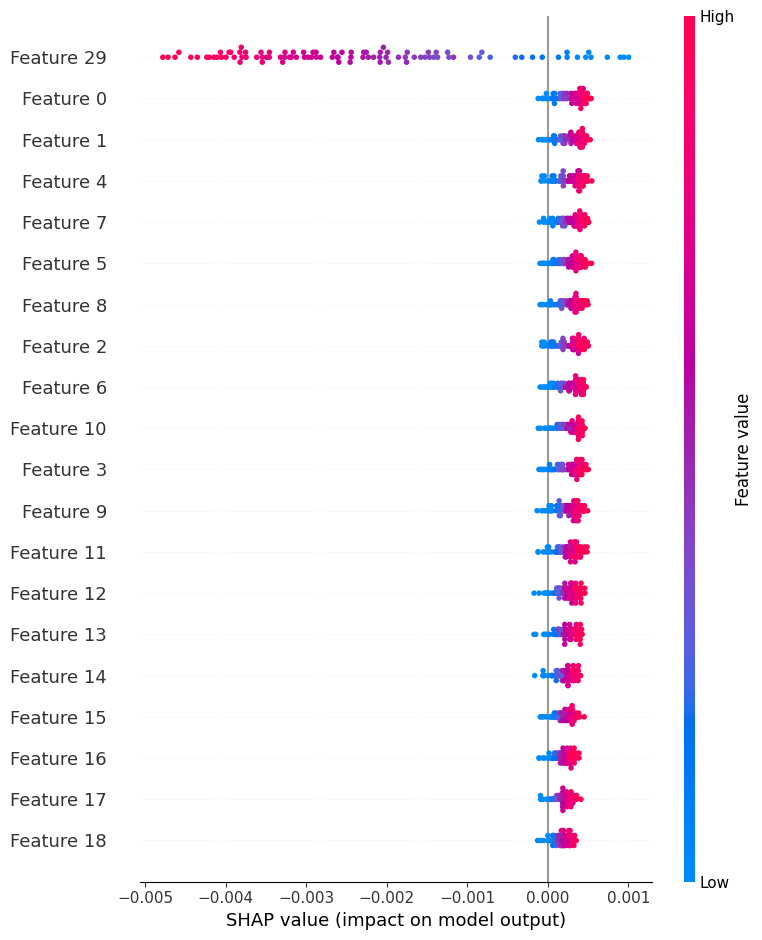

In [7]:
# Create SHAP Kernel Explainer
explainer = shap.KernelExplainer(model_predict, background_flat)

# Explain predictions for data_samples
shap_values = explainer.shap_values(data_samples_flat)

# Visualize the SHAP values
shap.summary_plot(shap_values, data_samples_flat)


### XAI - Features importance plot

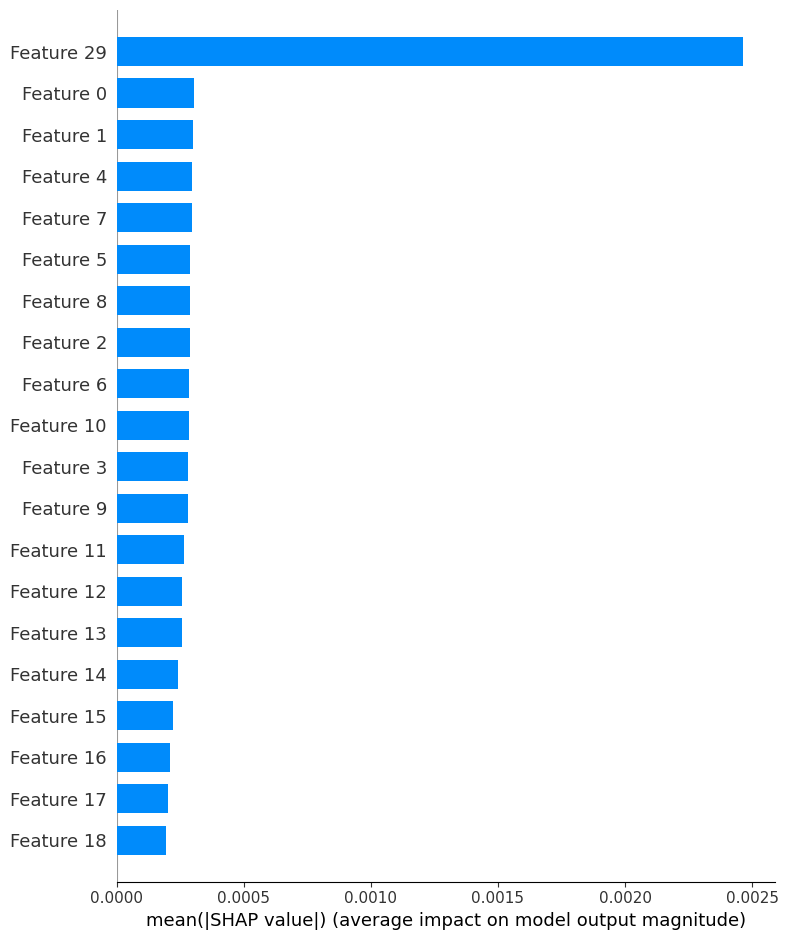

In [8]:
# Visualize the SHAP values
shap.summary_plot(shap_values, data_samples_flat, plot_type='bar')

### XAI - SHAP dependence plot

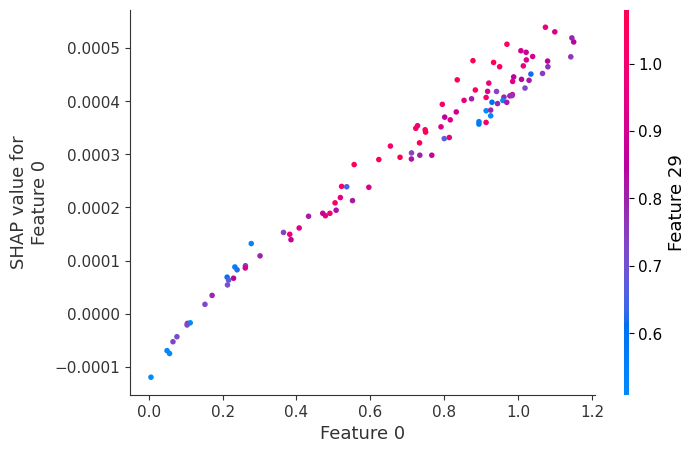

In [11]:
# Vẽ Dependence Plot cho một đặc trưng cụ thể (ví dụ: "Feature_1")
shap.dependence_plot(0, shap_values, data_samples_flat)

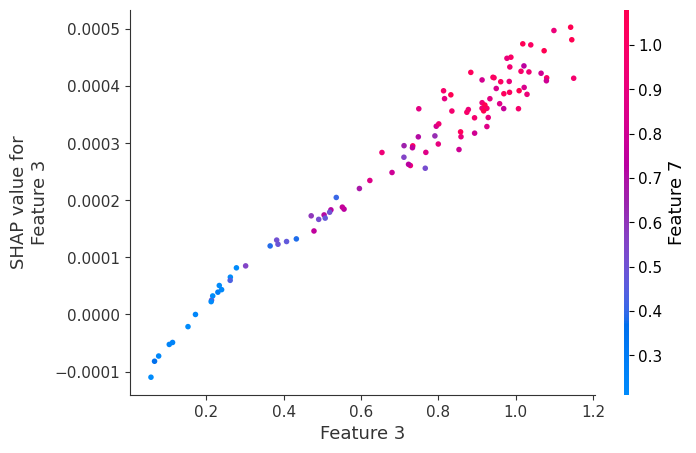

In [21]:
# (Tùy chọn) Vẽ Dependence Plot và làm rõ tương tác với đặc trưng khác
shap.dependence_plot(3, shap_values, data_samples_flat, interaction_index=7)

### XAI - Attention map plot

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

Shape of SHAP matrix: (100, 30)
Shape of shap_avg: (30, 1)


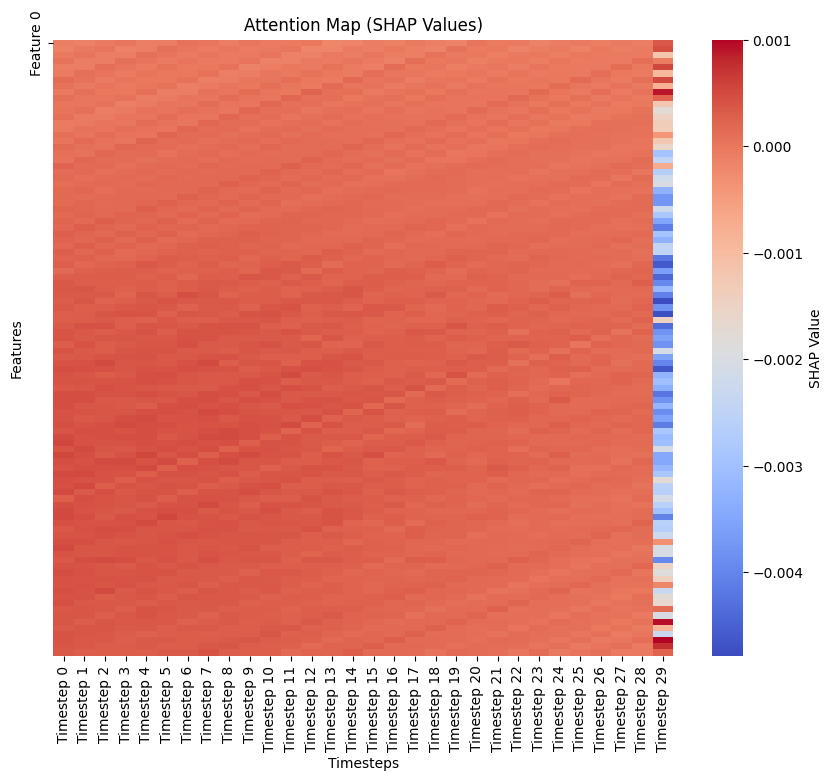

In [43]:
# 2. Lấy SHAP values liên quan đến mỗi token (bước thời gian)
shap_matrix = np.array([shap_values[i] for i in range(len(data_samples))])  # Shape: (num_samples, num_timesteps, num_features)

print("Shape of SHAP matrix:", shap_matrix.shape)
# Tính trung bình SHAP values dọc theo các mẫu (num_samples)
shap_avg = np.mean(shap_matrix, axis=0).reshape(-1, 1)  # Đảm bảo 2D


# Kiểm tra kích thước của shap_avg
print("Shape of shap_avg:", shap_avg.shape)

# 3. Vẽ Attention Map
plt.figure(figsize=(10, 8))
sns.heatmap(
    shap_matrix,  # Truyền mảng 2D vào heatmap
    annot=False,
    cmap="coolwarm",
    xticklabels=[f"Timestep {i}" for i in range(shap_avg.shape[0])],  # Timestep labels
    yticklabels=[f"Feature {i}" for i in range(shap_avg.shape[1])],  # Feature labels
    cbar_kws={'label': 'SHAP Value'},
)
plt.title("Attention Map (SHAP Values)")
plt.xlabel("Timesteps")
plt.ylabel("Features")
plt.show()


### XAI - Time-step Attribution

Shape of shap_matrix: (100, 30)


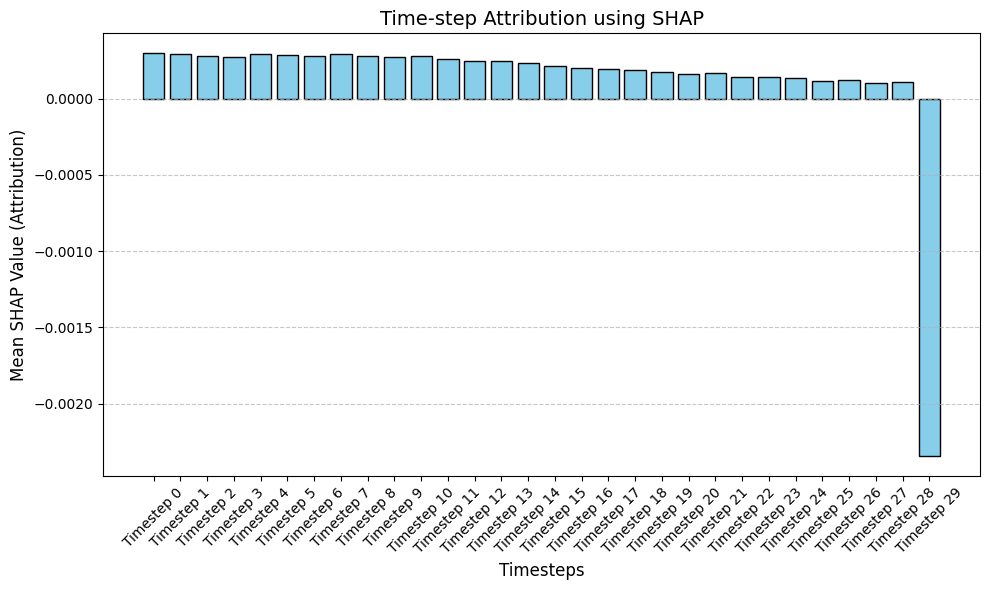

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo ma trận SHAP values
shap_matrix = np.array([shap_values[i] for i in range(len(data_samples))])  # Shape: (num_samples, num_timesteps)

# Kiểm tra kích thước ma trận
print("Shape of shap_matrix:", shap_matrix.shape)

# 2. Tính trung bình SHAP values trên các mẫu (num_samples)
timestep_attributions = np.mean(shap_matrix, axis=0)  # Shape: (num_timesteps,)

# 3. Vẽ biểu đồ Time-step Attribution
plt.figure(figsize=(10, 6))
plt.bar(range(len(timestep_attributions)), timestep_attributions, color='skyblue', edgecolor='black')
plt.title("Time-step Attribution using SHAP", fontsize=14)
plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean SHAP Value (Attribution)", fontsize=12)
plt.xticks(range(len(timestep_attributions)), [f"Timestep {i}" for i in range(len(timestep_attributions))], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### XAI - Waterfall plot

SHAP values for selected sample: [-6.95175410e-05 -1.15775707e-04 -4.03155462e-05  2.24699115e-05
 -8.54154838e-05 -6.87227356e-05  7.01305376e-05  2.96297816e-05
 -6.13339359e-05  1.56254437e-05 -3.99772272e-05 -5.66932739e-05
 -6.26974368e-06 -1.72519364e-04 -1.62313804e-04 -6.66322819e-05
 -1.10412210e-04 -1.70442287e-05 -9.01769552e-05 -1.32959092e-04
  4.83150719e-05 -4.24636413e-05 -3.18233935e-05 -1.28467227e-04
 -6.70360119e-05 -3.32896803e-05 -1.02296804e-04 -1.74654417e-05
 -6.41139067e-05  3.68017879e-04]


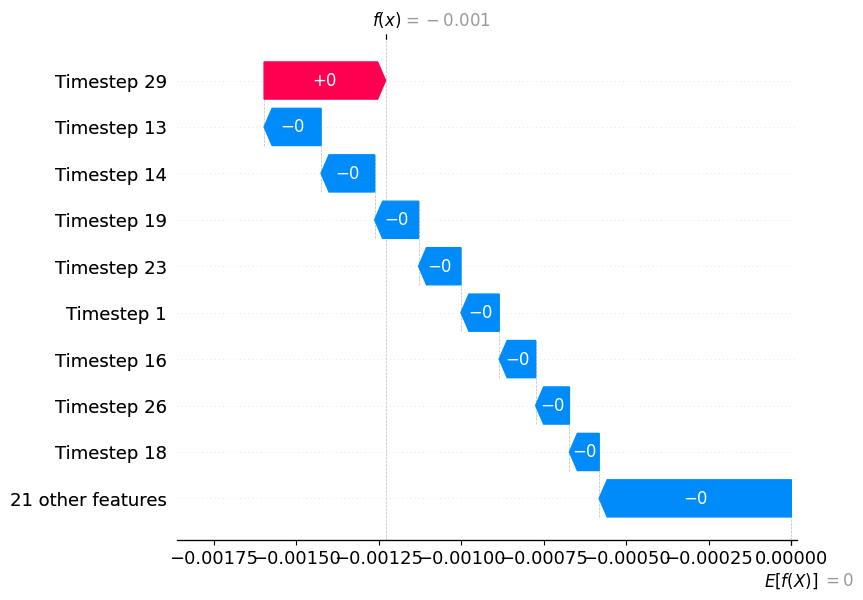

In [88]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Chọn mẫu cụ thể
sample_index = 0  # Thay đổi chỉ số mẫu nếu cần
selected_sample_shap_values = shap_matrix[sample_index]  # Shape: (num_timesteps,)

# 2. Tính tổng SHAP values dọc theo các đặc trưng (nếu cần)
# Giả sử shap_matrix đã tính tổng qua trục đặc trưng -> Chỉ có SHAP values theo timestep
print("SHAP values for selected sample:", selected_sample_shap_values)

# 3. Tạo dữ liệu đặc trưng cho Waterfall
feature_names = [f"Timestep {i}" for i in range(selected_sample_shap_values.shape[0])]
base_value = 0  # Giá trị cơ sở (giá trị mặc định, có thể là giá trị trung bình)

# Tạo đối tượng SHAP values
shap_explanation = shap.Explanation(
    values=selected_sample_shap_values, # Giá trị SHAP cho từng timestep
    base_values=base_value,             # Giá trị cơ sở (ví dụ: trung bình toàn bộ dự đoán)
    data=None,                          # Nếu có dữ liệu thô, có thể cung cấp (tùy chọn)
    feature_names=feature_names         # Tên các đặc trưng (timesteps)
)

# 4. Vẽ biểu đồ Waterfall
shap.plots.waterfall(shap_explanation)
